# Classification - Default of Credit Card Clients

**Problem statement:** Predict whether a credit card client will default on their payment next month (`default.payment.next.month`) based on demographic attributes, credit data, and payment history.

**Source:** UCI Machine Learning Repository, dataset 350.

## 1. Setup and reproducibility

In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
TARGET = "default"
FEATURES = None 

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

## 2. Dataset loading and audit

In [29]:
data_path = Path("data/classification.csv")

if not data_path.exists():
    data_path = Path("../data/classification.csv")

df = pd.read_csv(data_path)

column_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "default",
}

df.rename(
    columns=column_map,
    inplace=True
)

assert TARGET in df.columns, f"'{TARGET}' not found. Columns: {df.columns.tolist()}"

FEATURES = [
    c for c in df.columns if c not in (
        "ID",
        TARGET
    )
]

print(f"Shape: {df.shape}\n")
display(df.head())

Shape: (30000, 24)



,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [30]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean().mul(100).round(2),
        "unique_values": df.nunique(),
    }
)

display(audit)

print(f"Duplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_percent,unique_values
LIMIT_BAL,int64,0,0.0,81
SEX,int64,0,0.0,2
EDUCATION,int64,0,0.0,7
MARRIAGE,int64,0,0.0,4
AGE,int64,0,0.0,56
PAY_0,int64,0,0.0,11
PAY_2,int64,0,0.0,11
PAY_3,int64,0,0.0,11
PAY_4,int64,0,0.0,11
PAY_5,int64,0,0.0,10


Duplicate rows: 35


In [31]:
display(df.describe().T)
display(df[TARGET].value_counts(normalize=True).mul(100).round(2).to_frame("target_distribution_%"))

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


,target_distribution_%
default,
0,77.88
1,22.12


### Audit observation

The dataset contains 30,000 observations, 23 predictors, and one binary target, with no missing values. There are 35 exact duplicate rows. `EDUCATION` and `MARRIAGE` contain undocumented category codes (0, 5, 6 and 0 respectively). The target `default` is imbalanced at 77.9% (0) vs 22.1% (1).

# 3. Exploratory data analysis

## Target distribution

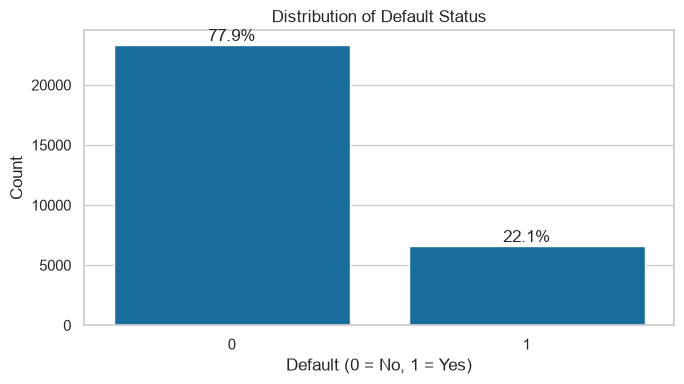

In [32]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x=TARGET, data=df)
total = len(df)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f"{pct:.1f}%", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.title("Distribution of Default Status")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()

**Observation:** The target is imbalanced - roughly 78% of clients did not default (0) versus 22% who did (1). Accuracy, weighted F1, confusion matrices, and a stratified train/test split will be used throughout.

## Feature distribution

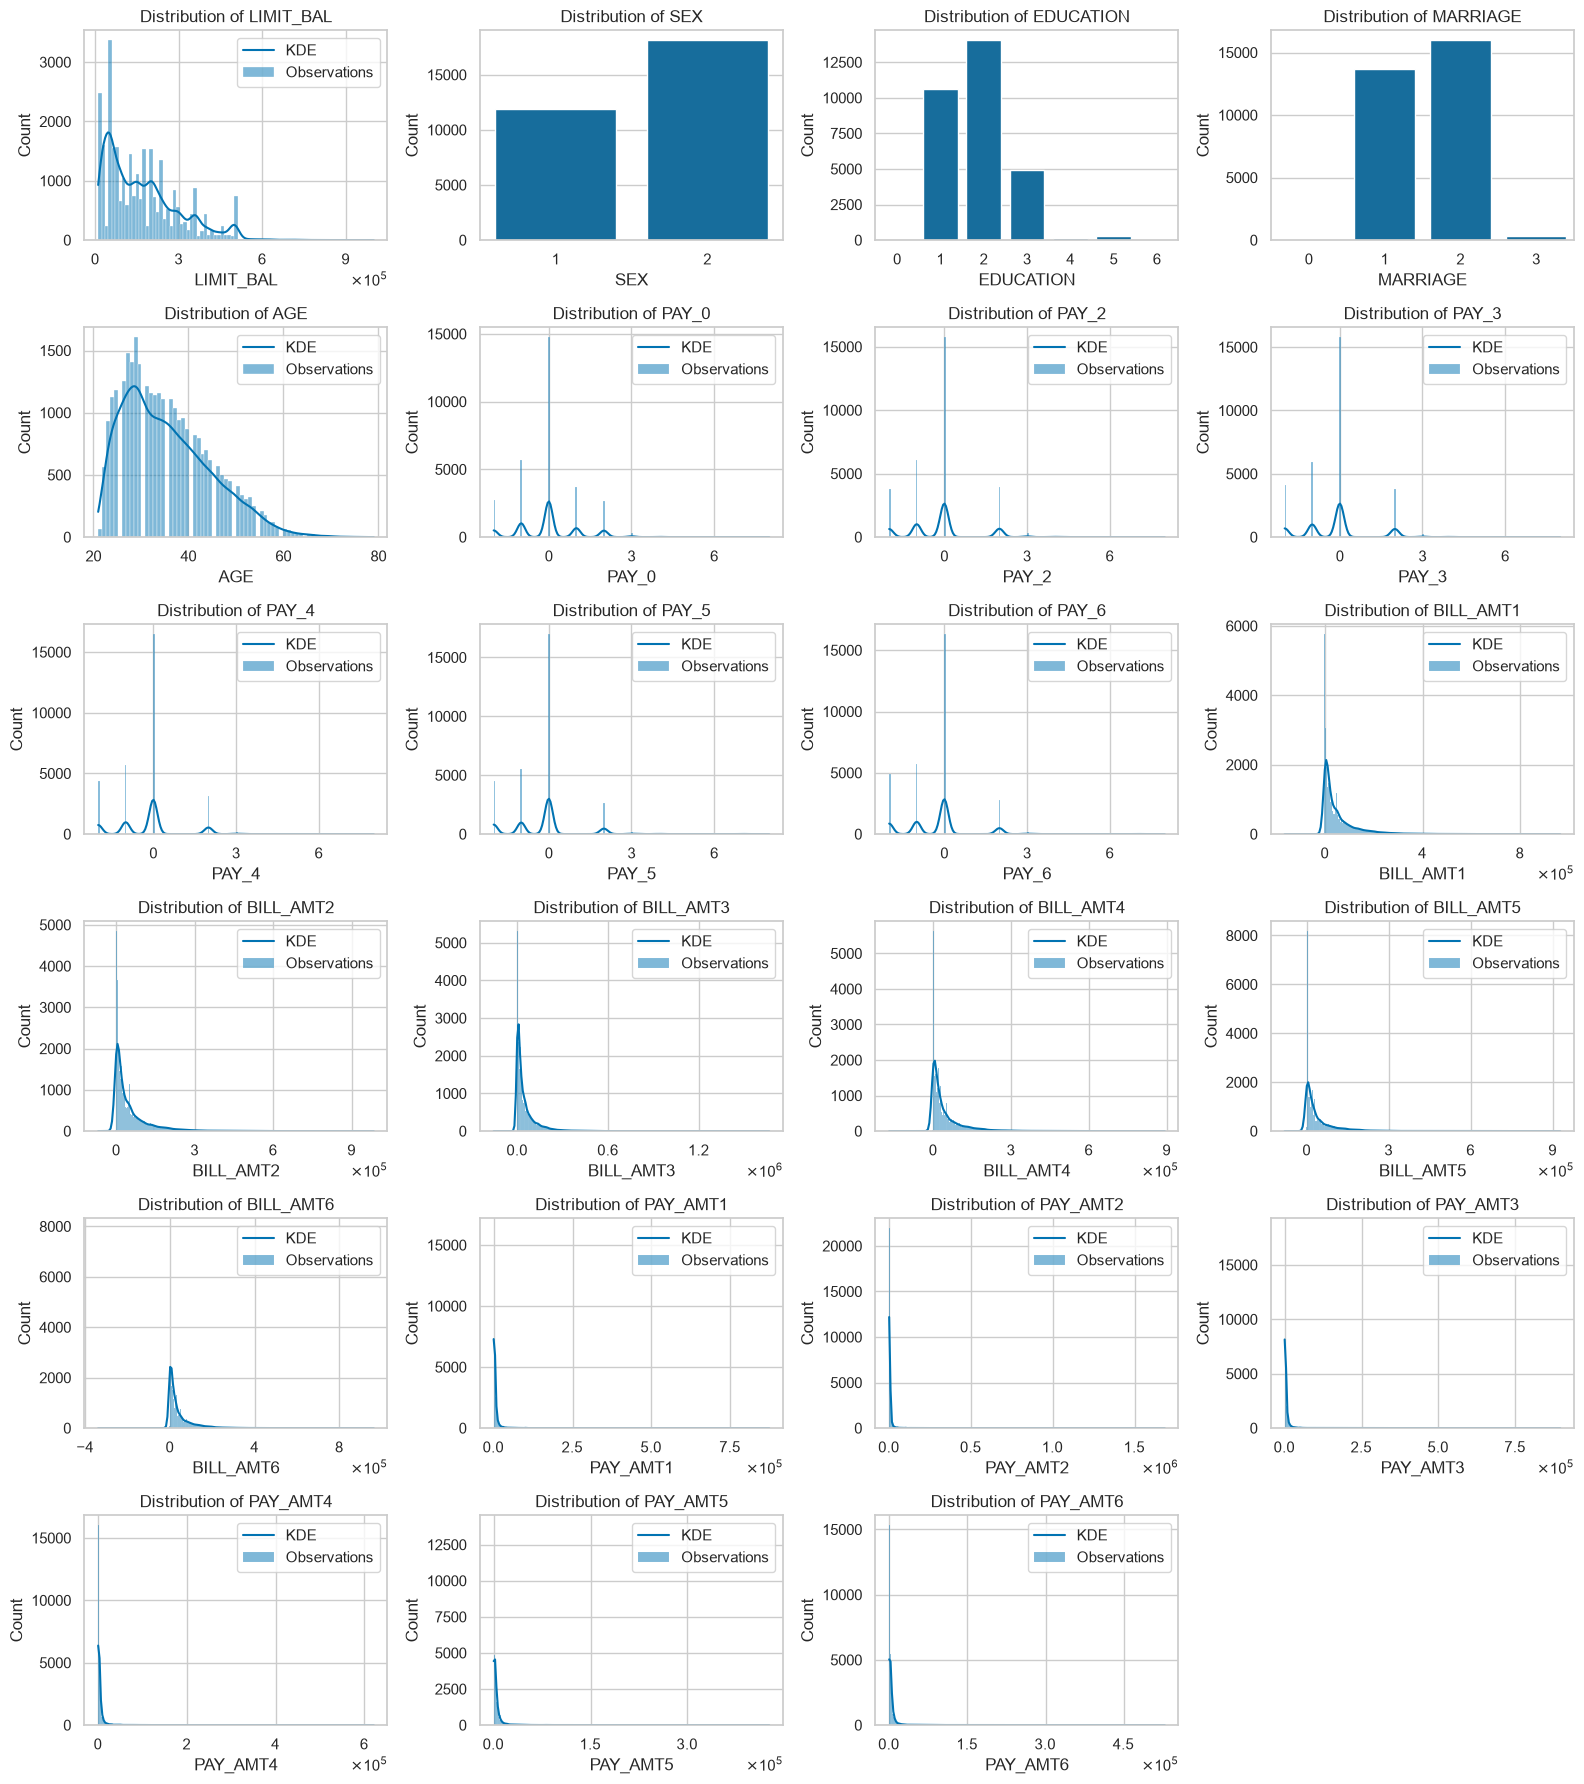

In [33]:
from matplotlib.ticker import MaxNLocator

n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for feature, axis in zip(FEATURES, axes.flat):
    if feature in ["SEX", "EDUCATION", "MARRIAGE"]:
        sns.countplot(data=df, x=feature, ax=axis)
    else:
        sns.histplot(df[feature], kde=True, label="Observations",
                     line_kws={"label": "KDE"}, ax=axis)
        axis.legend()
        axis.xaxis.set_major_locator(MaxNLocator(nbins=4))
        if feature == "LIMIT_BAL" or feature.startswith(("BILL_AMT", "PAY_AMT")):
            axis.ticklabel_format(axis="x", style="sci", scilimits=(0, 0), useMathText=True)
    axis.set(title=f"Distribution of {feature}", xlabel=feature, ylabel="Count")

for axis in axes.flat[len(FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()

**Observation:** Most monetary columns (`LIMIT_BAL`, `BILL_AMT1`-`BILL_AMT6`, `PAY_AMT1`-`PAY_AMT6`) are heavily right-skewed, with a long tail of high-value clients and a mass near zero; some `BILL_AMT` columns also contain negative values (overpayments/credits). `AGE` is mildly right-skewed, concentrated between 25-45. `SEX`, `EDUCATION`, and `MARRIAGE` are categorical codes rather than continuous distributions, and `EDUCATION`/`MARRIAGE` show unexpected categories (0, 5, 6) beyond their documented range. `PAY_0`-`PAY_6` cluster heavily around 0 and -1 (on-time/duly-paid), with a smaller spread of positive values indicating payment delay in months.

## Correlation heatmap

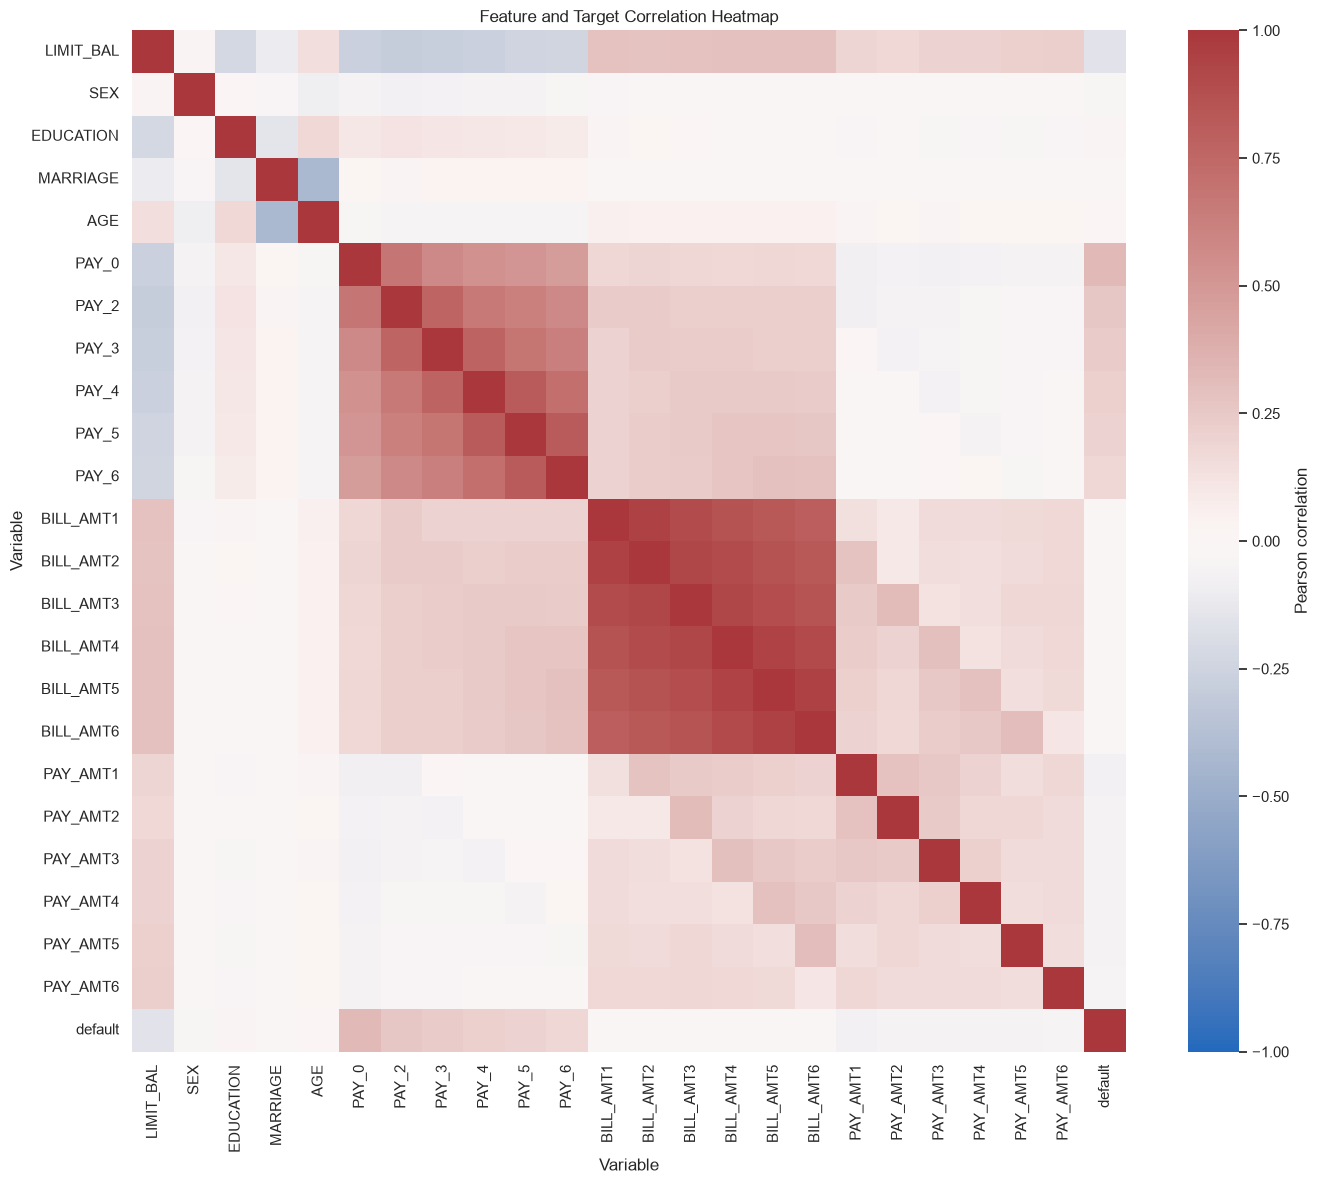

In [34]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation"})
plt.title("Feature and Target Correlation Heatmap")
plt.xlabel("Variable")
plt.ylabel("Variable")
plt.tight_layout()

**Observation:** `PAY_0` through `PAY_6` show the strongest positive correlation with `default`, consistent with recent repayment history being the most predictive signal. `BILL_AMT1`-`BILL_AMT6` are highly correlated with each other (multicollinear). `LIMIT_BAL` shows a mild negative correlation with `default`. Demographic features (`SEX`, `AGE`, `EDUCATION`, `MARRIAGE`) show weak correlation with the target individually.

## Feature target relationships

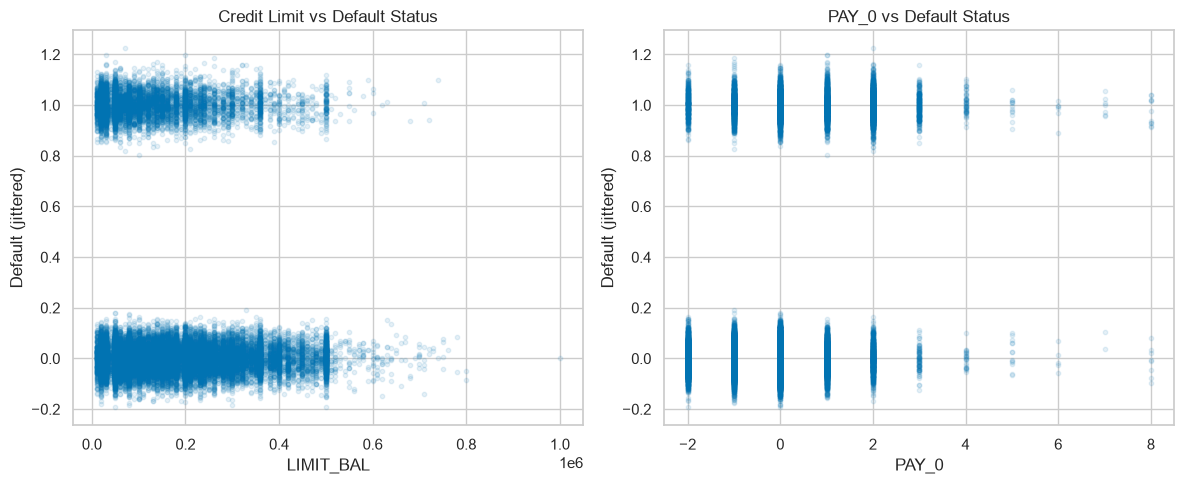

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

jitter = np.random.normal(0, 0.05, size=len(df))

axes[0].scatter(df["LIMIT_BAL"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[0].set(title="Credit Limit vs Default Status", xlabel="LIMIT_BAL", ylabel="Default (jittered)")

axes[1].scatter(df["PAY_0"], df[TARGET] + jitter, alpha=0.1, s=10)
axes[1].set(title="PAY_0 vs Default Status", xlabel="PAY_0", ylabel="Default (jittered)")

plt.tight_layout()

**Observation:** The binary target is jittered vertically to show overlapping observations. Both classes occur across credit limits and repayment statuses. Default is more frequent at delayed repayment statuses; the raw-data default rates are 69.1% at `PAY_0=2` and 50.0% at `PAY_0=5`. Scatter density also reflects group size.

# 4. Cleaning, outliers, feature engineering, and splitting

## Data cleaning

In [36]:
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows before removal: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")
print(f"Shape after removing duplicates: {df.shape}")

print("Before cleaning:")
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("\nAfter cleaning:")
print(df["EDUCATION"].value_counts())
print(df["MARRIAGE"].value_counts())

Missing values: 0
Duplicate rows before removal: 35
Duplicate rows after removal: 0
Shape after removing duplicates: (29965, 24)
Before cleaning:
EDUCATION
2    14019
1    10563
3     4915
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15945
1    13643
3      323
0       54
Name: count, dtype: int64

After cleaning:
EDUCATION
2    14019
1    10563
3     4915
4      468
Name: count, dtype: int64
MARRIAGE
2    15945
1    13643
3      377
Name: count, dtype: int64


In [37]:
q1 = df[FEATURES].quantile(0.25)
q3 = df[FEATURES].quantile(0.75)
iqr = q3 - q1
outlier_mask = (df[FEATURES] < (q1 - 1.5 * iqr)) | (df[FEATURES] > (q3 + 1.5 * iqr))
outlier_summary = pd.DataFrame({
    "lower_bound": q1 - 1.5 * iqr,
    "upper_bound": q3 + 1.5 * iqr,
    "iqr_outlier_count": outlier_mask.sum(),
})
display(outlier_summary)

,lower_bound,upper_bound,iqr_outlier_count
LIMIT_BAL,-235000.0,525000.0,167
SEX,-0.5,3.5,0
EDUCATION,-0.5,3.5,468
MARRIAGE,-0.5,3.5,0
AGE,8.5,60.5,272
PAY_0,-2.5,1.5,3129
PAY_2,-2.5,1.5,4409
PAY_3,-2.5,1.5,4208
PAY_4,-2.5,1.5,3507
PAY_5,-2.5,1.5,2967


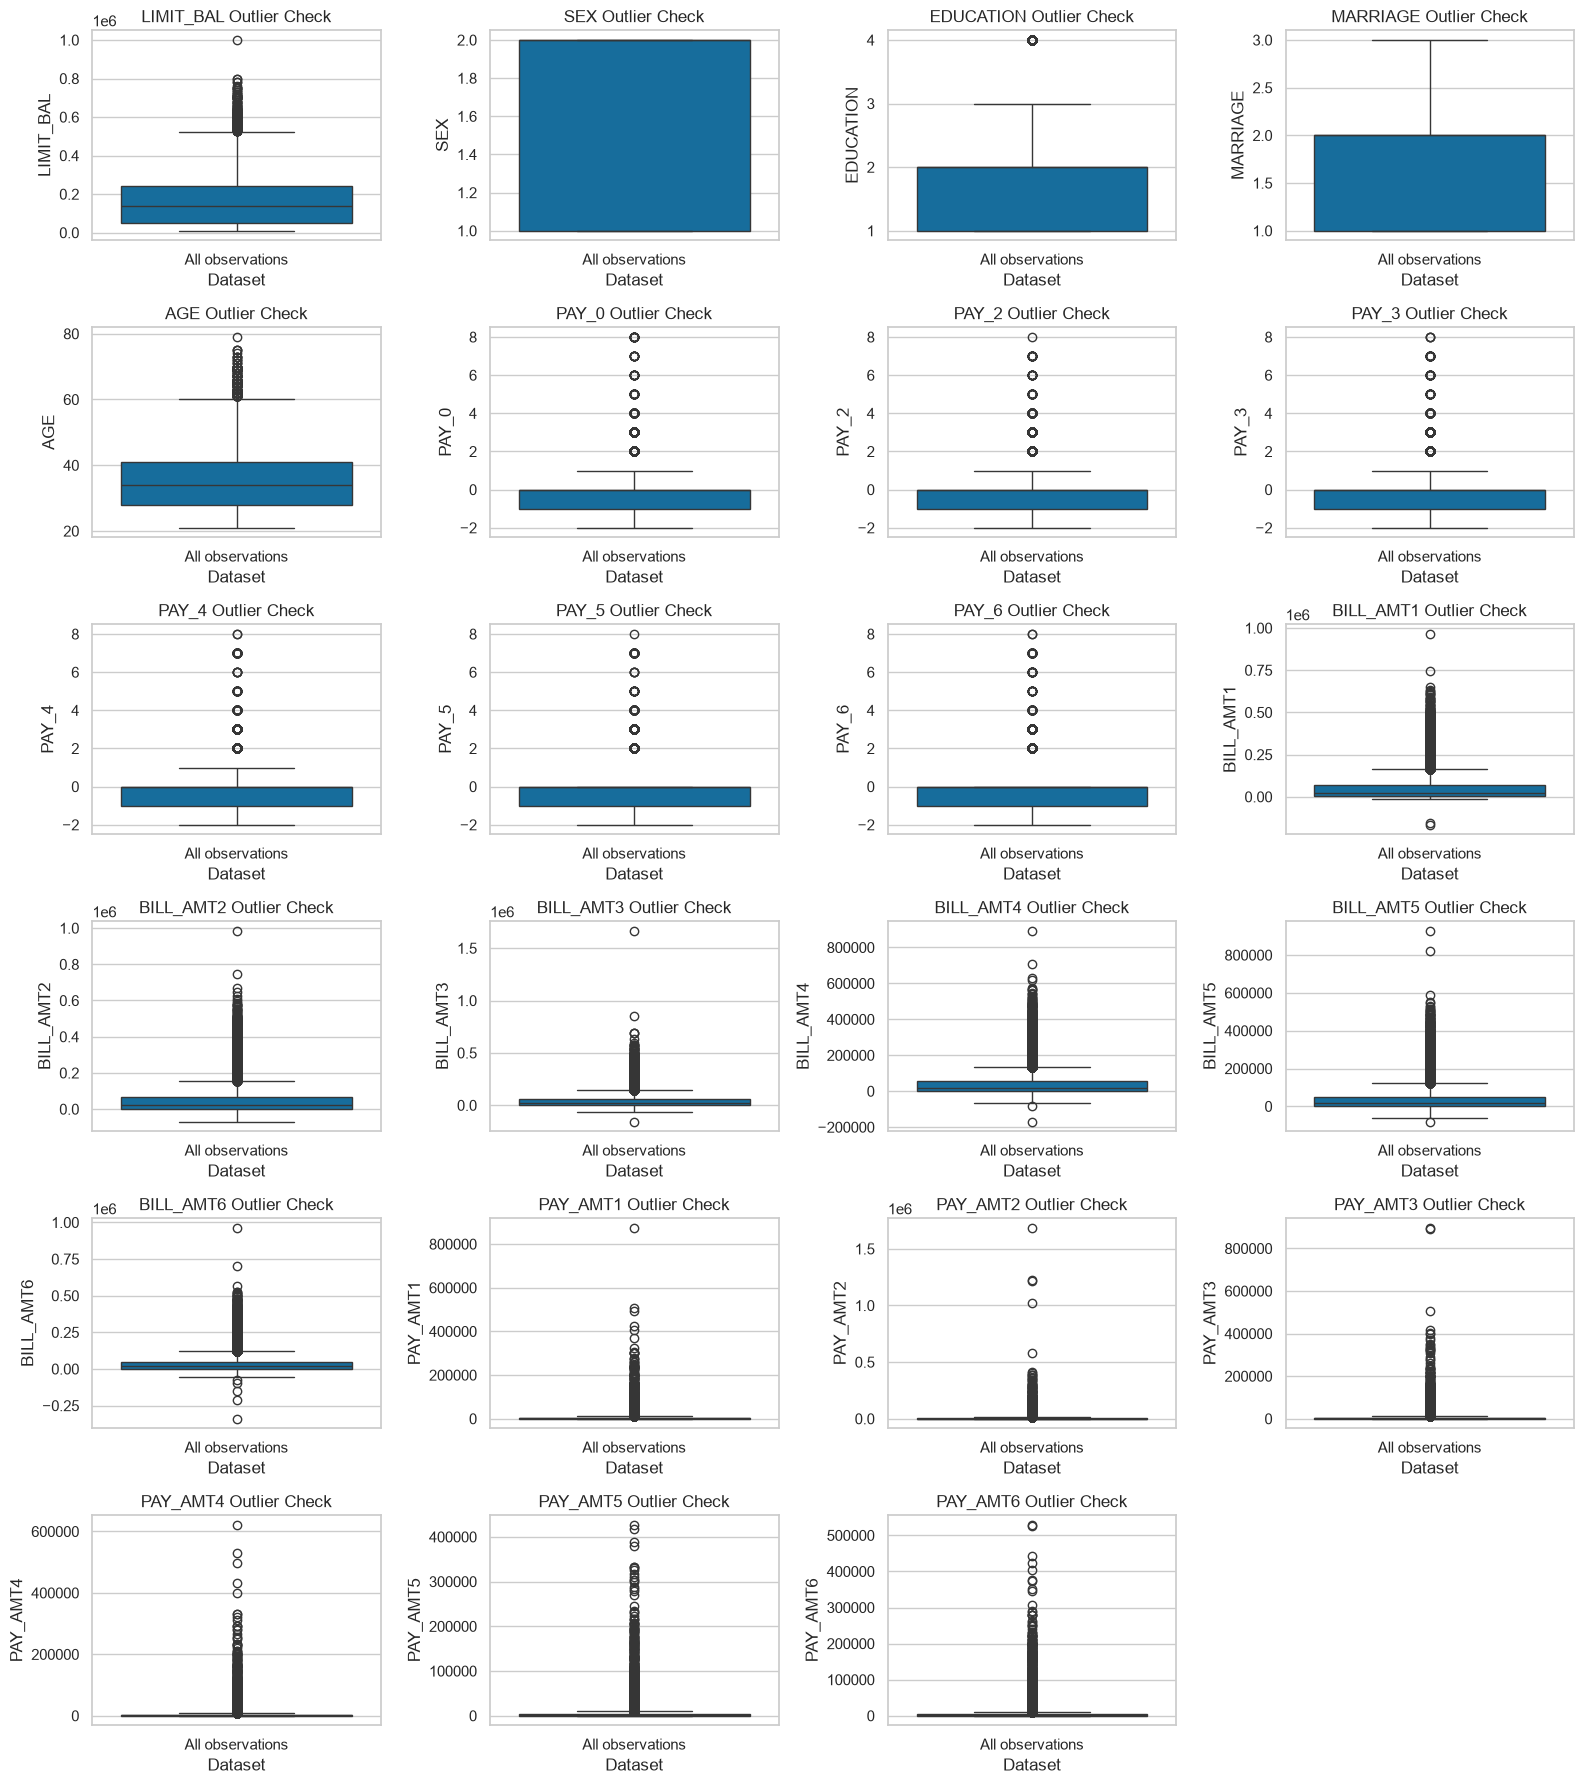

In [38]:
n_cols = 4
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))

for feature, axis in zip(FEATURES, axes.flat):
    sns.boxplot(y=df[feature], ax=axis)
    axis.set(title=f"{feature} Outlier Check", xlabel="Dataset", ylabel=feature)
    axis.set_xticks([0], ["All observations"])

for axis in axes.flat[len(FEATURES):]:
    axis.set_visible(False)

plt.tight_layout()

**Observation:** No missing values were found, so imputation is unnecessary. Removing 35 exact duplicate rows leaves 29,965 observations before splitting. The undocumented `EDUCATION` codes 0, 5, and 6 account for 345 rows, and `MARRIAGE=0` accounts for 54.

## Feature engineering

In [39]:
bill_cols = [c for c in df.columns if c.startswith("BILL_AMT")]
pay_cols = [c for c in df.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]

df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)
df["UTILIZATION_RATIO"] = (df["AVG_BILL_AMT"] / df["LIMIT_BAL"]).clip(lower=0)
df["DELAY_MONTHS_COUNT"] = (df[pay_cols] > 0).sum(axis=1)

FEATURES = FEATURES + ["AVG_BILL_AMT", "UTILIZATION_RATIO", "DELAY_MONTHS_COUNT"]

df[["AVG_BILL_AMT", "UTILIZATION_RATIO", "DELAY_MONTHS_COUNT"]].describe()

,AVG_BILL_AMT,UTILIZATION_RATIO,DELAY_MONTHS_COUNT
count,29965.000000,29965.000000,29965.000000
mean,45029.328116,0.373572,0.834273
std,63279.074163,0.351758,1.554821
min,-56043.166667,0.000000,0.000000
25%,4841.000000,0.030300,0.000000
50%,21110.833333,0.285629,0.000000
75%,57166.166667,0.688454,1.000000
max,877313.833333,5.364308,6.000000


### Justification 

Three features augment the original inputs: `AVG_BILL_AMT` summarises the six monthly balances, and the two features below express utilisation and repayment history.

**`UTILIZATION_RATIO`** (average bill amount ÷ credit limit) captures how much of their available credit a client typically uses.

**`DELAY_MONTHS_COUNT`** (number of the last 6 months with a delayed payment, derived from `PAY_0`-`PAY_6`) condenses six separate monthly repayment-status columns into a single interpretable count. This may improve model performance because it summarises a repeated pattern of delinquency into one strong, aggregated signal.

## Scaling and splitting 

In [40]:
from sklearn.model_selection import train_test_split

categorical_features = ["EDUCATION", "MARRIAGE"]
numeric_features = [feature for feature in FEATURES if feature not in categorical_features]

X = df[FEATURES].copy()
y = df[TARGET].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "raw_feature_columns": [X_train.shape[1], X_test.shape[1]],
    "default_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
display(split_summary.round(3))

,rows,raw_feature_columns,default_rate
train,23972,26,0.221
test,5993,26,0.221


### Preprocessing justification

`EDUCATION` and `MARRIAGE` are nominal fields, so their integer codes are one-hot encoded inside each model pipeline. The encoder discovers categories only from the current training fold; the fitted encoder then transforms validation or test rows. `SEX` remains binary-coded.

The stratified 80:20 split contains 23,972 training rows and 5,993 test rows, with approximately 22.1% defaults in each partition.

For Logistic Regression, KNN, and SVM, numeric predictors are standardised inside the pipeline using training-fold means and standard deviations. One-hot indicators remain 0/1. Decision Tree and Gaussian Naive Bayes use the same categorical encoding with unscaled numeric predictors.

## 5. Model training and evaluation - Classification part A

In [41]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scaled_preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
], verbose_feature_names_out=False)
unscaled_preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
], verbose_feature_names_out=False)

In [42]:
search_spaces = {
    "Logistic Regression": (
        Pipeline([("preprocess", scaled_preprocessor), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        {"model__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "K-Nearest Neighbors": (
        Pipeline([("preprocess", scaled_preprocessor), ("model", KNeighborsClassifier(n_jobs=-1))]),
        {"model__n_neighbors": [3, 5, 9, 15], "model__weights": ["uniform", "distance"]},
    ),
    "Naive Bayes": (
        Pipeline([("preprocess", unscaled_preprocessor), ("model", GaussianNB())]),
        {"model__var_smoothing": [1e-9, 1e-8, 1e-7]},
    ),
    "Decision Tree": (
        Pipeline([("preprocess", unscaled_preprocessor), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        {"model__max_depth": [5, 10, 15, None], "model__min_samples_leaf": [1, 5, 10]},
    ),
    "SVM": (
        Pipeline([("preprocess", scaled_preprocessor), ("model", SVC(random_state=RANDOM_STATE))]),
        {"model__C": [1.0, 10.0], "model__kernel": ["linear", "rbf"]},
    ),
}

In [43]:
# Use a stratified sample only for SVM parameter search; refit the winner on all training rows.
X_svm_sample, _, y_svm_sample, _ = train_test_split(
    X_train, y_train, train_size=5000, random_state=RANDOM_STATE, stratify=y_train
)

In [44]:
grid_results = {}
predictions = {}
roc_scores = {}
tuning_rows = []

for name, (estimator, param_grid) in search_spaces.items():
    grid = GridSearchCV(estimator, param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1)
    if name == "SVM":
        grid.fit(X_svm_sample, y_svm_sample)
        grid.best_estimator_.fit(X_train, y_train)
    else:
        grid.fit(X_train, y_train)
    grid_results[name] = grid
    predictions[name] = grid.best_estimator_.predict(X_test)
    roc_scores[name] = (grid.best_estimator_.decision_function(X_test) if name == "SVM"
                        else grid.best_estimator_.predict_proba(X_test)[:, 1])
    tuning_rows.append({
        "Model": name,
        "Tuning rows": len(X_svm_sample) if name == "SVM" else len(X_train),
        "Best tuning CV weighted F1": grid.best_score_,
        "Best parameters": grid.best_params_,
        "Final training rows": len(X_train),
    })

tuning_results = pd.DataFrame(tuning_rows)
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(tuning_results.round(4))

,Model,Tuning rows,Best tuning CV weighted F1,Best parameters,Final training rows
0,Logistic Regression,23972,0.7779,{'model__C': 10.0},23972
1,K-Nearest Neighbors,23972,0.7856,"{'model__n_neighbors': 15, 'model__weights': 'uniform'}",23972
2,Naive Bayes,23972,0.3951,{'model__var_smoothing': 1e-09},23972
3,Decision Tree,23972,0.7944,"{'model__max_depth': 5, 'model__min_samples_leaf': 10}",23972
4,SVM,5000,0.7772,"{'model__C': 1.0, 'model__kernel': 'rbf'}",23972


In [45]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

results = []
for name, y_pred in predictions.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_test, roc_scores[name]),
    })

results_df = pd.DataFrame(results).sort_values("Weighted F1", ascending=False).reset_index(drop=True)
display(results_df.round(3))

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Decision Tree,0.815,0.796,0.815,0.796,0.757
1,SVM,0.816,0.798,0.816,0.793,0.712
2,K-Nearest Neighbors,0.809,0.787,0.809,0.786,0.738
3,Logistic Regression,0.812,0.792,0.812,0.781,0.750
4,Naive Bayes,0.389,0.730,0.389,0.391,0.680


### Confusion matrix

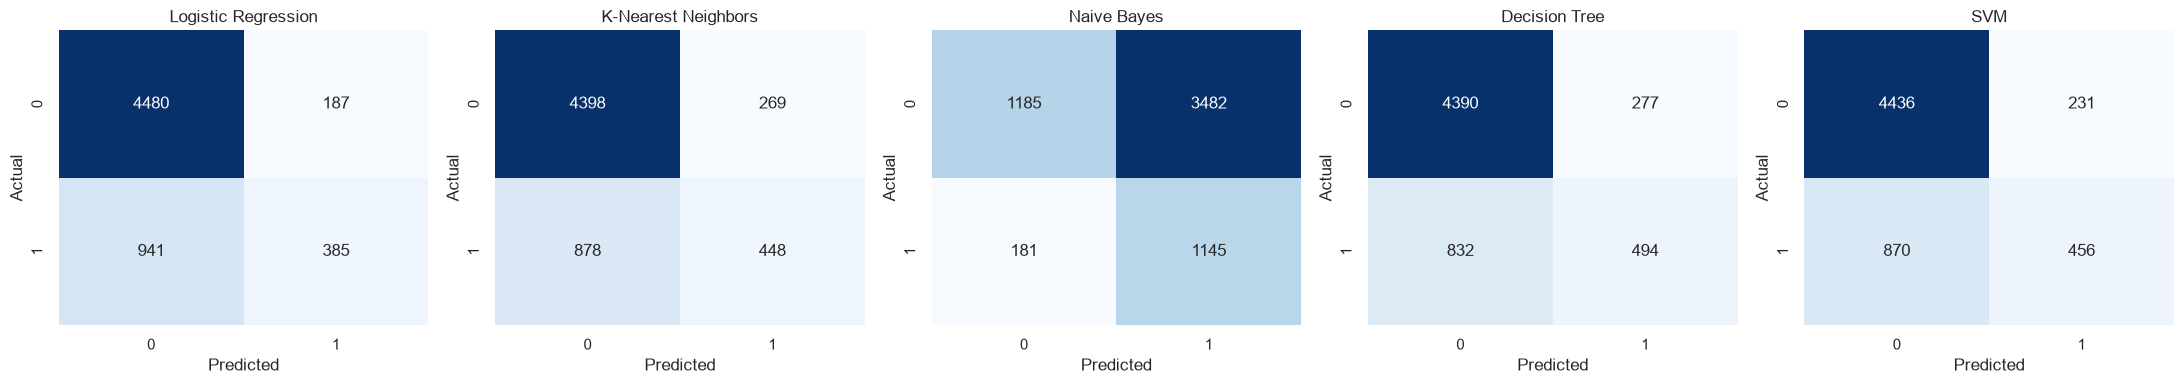

In [46]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for axis, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axis, cbar=False)
    axis.set(title=name, xlabel="Predicted", ylabel="Actual")

plt.tight_layout()

**Observation:** Naive Bayes catches 1,145 defaults but falsely flags 3,482 non-defaulters. Decision Tree has 277 false positives and misses 832 defaults; Logistic Regression has fewer false positives (187) but more missed defaults (941). These matrices show why the roughly 81% accuracy of several models does not imply strong default detection.

### Logistic Regression coefficients

In [47]:
best_lr = grid_results["Logistic Regression"].best_estimator_
preprocessor = best_lr.named_steps["preprocess"]
coefs = pd.Series(best_lr.named_steps["model"].coef_[0], index=preprocessor.get_feature_names_out())
numeric_scales = pd.Series(preprocessor.named_transformers_["numeric"].scale_, index=numeric_features)

coef_df = pd.DataFrame({
    "Feature": coefs.index,
    "Coefficient": coefs.values,
    "exp(coefficient)": np.exp(coefs.values),
    "Unit": ["1 training SD" if feature in numeric_features else "0-to-1 indicator" for feature in coefs.index],
    "Odds ratio per original numeric unit": np.exp(coefs / numeric_scales.reindex(coefs.index)).values,
}).sort_values("Coefficient", ascending=False)

display(coef_df.round(4))

,Feature,Coefficient,exp(coefficient),Unit,Odds ratio per original numeric unit
23,DELAY_MONTHS_COUNT,0.8125,2.2534,1 training SD,1.6883
10,BILL_AMT2,0.3445,1.4113,1 training SD,1.0000
3,PAY_0,0.3372,1.4010,1 training SD,1.3507
11,BILL_AMT3,0.0388,1.0396,1 training SD,1.0000
2,AGE,0.0252,1.0256,1 training SD,1.0027
22,UTILIZATION_RATIO,0.0230,1.0232,1 training SD,1.0673
21,AVG_BILL_AMT,0.0153,1.0154,1 training SD,1.0000
17,PAY_AMT3,0.0022,1.0022,1 training SD,1.0000
14,BILL_AMT6,-0.0095,0.9906,1 training SD,1.0000
12,BILL_AMT4,-0.0100,0.9901,1 training SD,1.0000


**Interpretation:** Numeric coefficients describe a one-training-standard-deviation increase with other model inputs fixed. Their original-unit odds multipliers are `exp(coefficient / training_scale)`. For `DELAY_MONTHS_COUNT`, the fitted odds multiplier is 2.2534 per training standard deviation, equivalent to 1.6883 per additional month with delayed payment. The other model inputs are held fixed in this interpretation.

Categorical indicators are not standardised. Because all one-hot columns are retained, the odds multiplier for switching between categories A and B is `exp(coefficient_B - coefficient_A)`.

### KNN

In [48]:
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    display(tuning_results[tuning_results["Model"] == "K-Nearest Neighbors"].reset_index(drop=True).round(4))

,Model,Tuning rows,Best tuning CV weighted F1,Best parameters,Final training rows
0,K-Nearest Neighbors,23972,0.7856,"{'model__n_neighbors': 15, 'model__weights': 'uniform'}",23972


**Observation:** The grid selects 15 neighbours with uniform weighting, with a mean CV weighted F1 of 0.7856.

### Decision Tree Visualisation

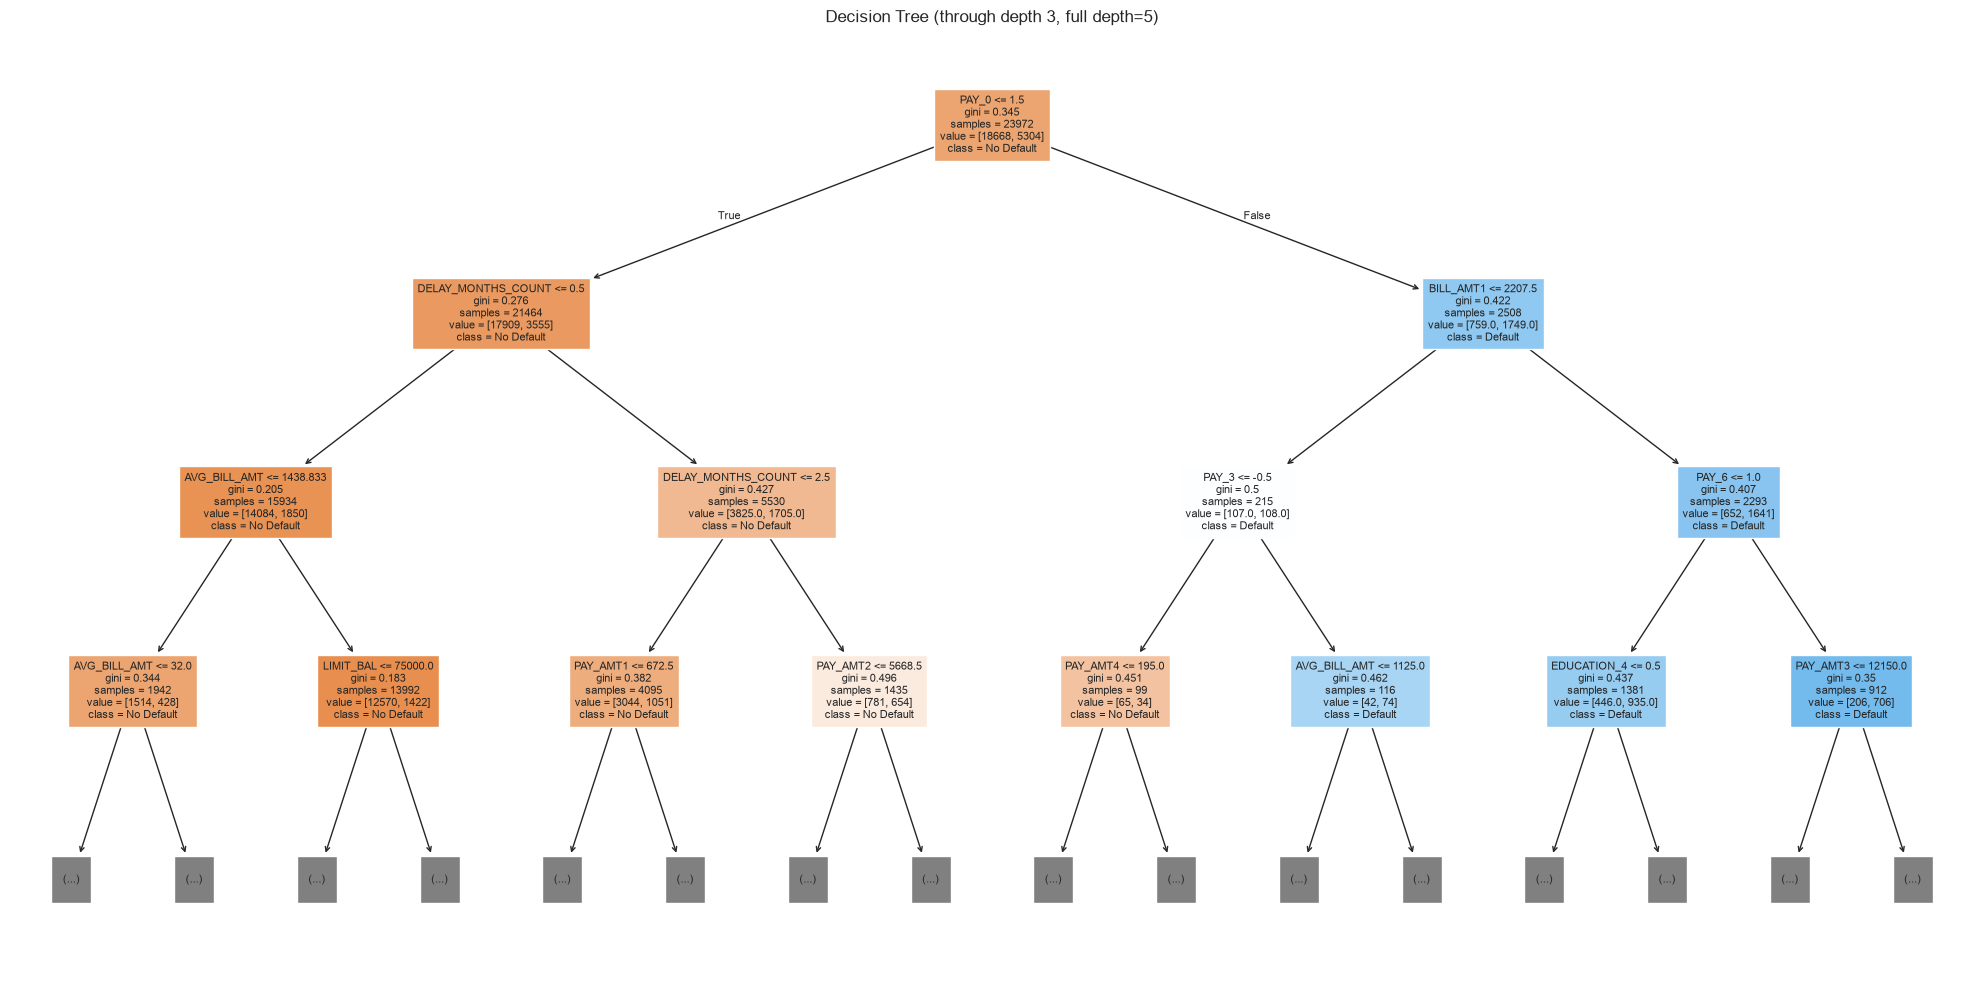

In [49]:
from sklearn.tree import plot_tree

best_dt_pipeline = grid_results["Decision Tree"].best_estimator_
best_dt = best_dt_pipeline.named_steps["model"]
tree_feature_names = best_dt_pipeline.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(best_dt, feature_names=tree_feature_names, class_names=["No Default", "Default"],
          filled=True, max_depth=3, fontsize=8)
plt.title(f"Decision Tree (through depth 3, full depth={best_dt.get_depth()})")
plt.tight_layout()
plt.show()

**Observation:** The diagram shows the root and splits through depth 3; grey ellipses indicate omitted descendants. Node sample counts and class totals show which training observations reach each branch, while the class label gives that node's majority class. The root splits on `PAY_0` at 1.5, and `DELAY_MONTHS_COUNT` appears in the next split on the left branch.

### SVM

**Method:** Numeric scaling and nominal-category encoding are fitted inside the SVM pipeline. Parameter search uses a stratified sample of 5,000 training rows to limit search cost. ROC-AUC uses the SVM decision scores, which rank observations without requiring probability calibration. The tuning table labels the smaller search sample explicitly.

### Naive Bayes assumptions

Gaussian Naive Bayes assumes features are conditionally independent given the class and models each class-conditional feature distribution as Gaussian. The monthly bills and payments are correlated, and `AVG_BILL_AMT` is derived from the bills. Binary one-hot indicators and skewed monetary features also do not follow continuous Gaussian distributions. These limitations help explain why this required baseline can behave differently from the other classifiers.

### Cross-validation of the two leading models

The two models with the highest held-out weighted F1 are evaluated with five stratified folds over the same full training partition, with preprocessing refitted within each fold. These scores describe fixed selected hyperparameters.

In [50]:
cv_rows = []
for name in results_df.head(2)["Model"]:
    estimator = clone(grid_results[name].best_estimator_)
    scores = cross_val_score(estimator, X_train, y_train, scoring="f1_weighted", cv=cv, n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "Training rows": len(X_train),
        "Mean CV weighted F1": scores.mean(),
        "CV weighted F1 std": scores.std(),
    })
cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(4))

,Model,Training rows,Mean CV weighted F1,CV weighted F1 std
0,Decision Tree,23972,0.7944,0.0040
1,SVM,23972,0.7976,0.0068
